In [1]:
import sys

if "google.colab" in sys.modules:
    !pip install requests torch numpy matplotlib scipy -q
else:
    !~/.local/bin/uv pip install --python {sys.executable} requests torch numpy matplotlib scipy --quiet

In [ ]:
import os
import base64
import struct
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import requests

In [ ]:
# ── Model persistence config ──────────────────────────────────────────────────
SAVE_MODELS = True        # save/load models to avoid retraining
MODEL_DIR   = Path(".")   # local directory for .pt files

ANNEALING_PATH      = MODEL_DIR / "annealing_model.pt"
STE_PATH            = MODEL_DIR / "ste_model.pt"
ANNEALING_REPO_PATH = "annealing_model.pt"
STE_REPO_PATH       = "ste_model.pt"

# ── GitHub sync config ────────────────────────────────────────────────────────
# In Colab: open the Secrets panel (key icon), add GITHUB_TOKEN, then run:
#   import os; from google.colab import userdata
#   os.environ["GITHUB_TOKEN"] = userdata.get("GITHUB_TOKEN")
# Then re-run this cell to pick it up.
GITHUB_TOKEN  = os.environ.get("GITHUB_TOKEN", "")
GITHUB_REPO   = "arosen64/mario_autoencoder"
GITHUB_BRANCH = "main"

In [ ]:
def _gh_headers():
    return {"Authorization": f"token {GITHUB_TOKEN}", "Accept": "application/vnd.github.v3+json"}

def upload_to_github(local_path: Path, repo_path: str):
    """Upload a file to the GitHub repo via the Contents API."""
    url = f"https://api.github.com/repos/{GITHUB_REPO}/contents/{repo_path}"
    data = base64.b64encode(local_path.read_bytes()).decode()
    r = requests.get(url, headers=_gh_headers())
    sha = r.json().get("sha") if r.status_code == 200 else None
    payload = {"message": f"Save {repo_path}", "content": data, "branch": GITHUB_BRANCH}
    if sha:
        payload["sha"] = sha
    r = requests.put(url, json=payload, headers=_gh_headers())
    r.raise_for_status()

def download_from_github(repo_path: str, local_path: Path) -> bool:
    """Download a file from the GitHub repo; returns True on success."""
    url = f"https://raw.githubusercontent.com/{GITHUB_REPO}/{GITHUB_BRANCH}/{repo_path}"
    r = requests.get(url)
    if r.status_code == 200:
        local_path.write_bytes(r.content)
        return True
    return False

In [4]:
BUTTON_BITS = [
    0x8000, 0x4000, 0x2000, 0x1000,
    0x0800, 0x0400, 0x0200, 0x0100,
    0x0020, 0x0010, 0x0008, 0x0004, 0x0002, 0x0001,
]

# 6 output categories
CAT_NAMES = ["Directional", "A", "B", "Z/L/R", "Start", "No Input"]
INPUT_DIM  = 6

# Which columns of the 16-col base tensor [stick_x, stick_y, A..CRight] map to each category
#   col 0  = stick_x   col 1  = stick_y
#   col 2  = A         col 3  = B
#   col 4  = Z         col 5  = Start
#   col 6  = DUp       col 7  = DDown    col 8  = DLeft   col 9  = DRight
#   col 10 = L         col 11 = R
#   col 12 = CUp       col 13 = CDown    col 14 = CLeft   col 15 = CRight
CAT_COLS = [
    [0, 1, 6, 7, 8, 9, 12, 13, 14, 15], # Directional (Stick + D-Pad + C-Buttons)
    [2],                                  # A
    [3],                                  # B
    [4, 10, 11],                          # Z/L/R
    [5],                                  # Start
]


def parse_m64(raw: bytes) -> torch.Tensor:
    """Parse .m64 bytes into a (T, 6) binary float32 tensor — one column per category.
    Categories: [Directional, A, B, Z/L/R, Start, No Input]
    """
    version = struct.unpack_from("<I", raw, 0x004)[0]
    data_start = 0x200 if version in (1, 2) else 0x400
    num_samples = struct.unpack_from("<I", raw, 0x018)[0]

    buf = np.frombuffer(
        raw[data_start : data_start + num_samples * 4], dtype=np.uint8
    ).reshape(num_samples, 4)

    y_axis  = buf[:, 0].view(np.int8)
    x_axis  = buf[:, 1].view(np.int8)
    btn_raw = buf[:, 2].astype(np.uint16) * 256 + buf[:, 3].astype(np.uint16)
    buttons = np.stack(
        [(btn_raw & bit).astype(bool) for bit in BUTTON_BITS], axis=1
    ).astype(np.float32)

    stick_x = torch.from_numpy((x_axis != 0).astype(np.float32)).unsqueeze(1)
    stick_y = torch.from_numpy((y_axis != 0).astype(np.float32)).unsqueeze(1)
    btns    = torch.from_numpy(buttons)
    base    = torch.cat([stick_x, stick_y, btns], dim=1)  # (T, 16)

    cat_active = torch.stack(
        [base[:, cols].any(dim=1) for cols in CAT_COLS], dim=1
    ).float()  # (T, 5)

    no_input = (~cat_active.any(dim=1)).unsqueeze(1).float()
    return torch.cat([cat_active, no_input], dim=1)  # (T, 6)


def load_m64(source: str, cache_dir: str = ".") -> torch.Tensor:
    """Load an .m64 from a local path or URL, caching downloads locally."""
    if source.startswith("http://") or source.startswith("https://"):
        cache_path = Path(cache_dir) / Path(source).name
        if not cache_path.exists():
            print(f"Downloading {source} ...")
            cache_path.write_bytes(requests.get(source).content)
        raw = cache_path.read_bytes()
    else:
        raw = Path(source).read_bytes()
    return parse_m64(raw)

In [5]:
def expand_to_sequential(frames: torch.Tensor) -> torch.Tensor:
    """Convert (T, 6) multi-hot frames to (N, 6) sequential one-hot events.

    Each active category in a frame becomes its own entry in column order.
    A no-input frame → one one-hot vector at col 5.
    """
    events = []
    eye = torch.eye(INPUT_DIM)
    for frame in frames:
        for col in frame.nonzero(as_tuple=True)[0]:
            events.append(eye[col])
    return torch.stack(events)  # (N, 6)


class M64Dataset(Dataset):
    """Windowed one-hot matrix dataset over one or more .m64 files.

    Each item is a (window_size, 6) matrix of sequential one-hot event vectors,
    where each row is one input category event. Windows are drawn from the
    full sequential event stream concatenated across all source files.

    Args:
        sources:     list of local paths or URLs to .m64 files.
        window_size: number of one-hot events per sample matrix.
        cache_dir:   directory to cache downloaded files.
    """

    def __init__(self, sources: list[str], window_size: int = 64, cache_dir: str = "."):
        self.window_size = window_size
        self.file_names: list[str] = []
        events = []

        for file_idx, src in enumerate(sources):
            print(f"[{file_idx}] Loading: {src}")
            raw_frames = load_m64(src, cache_dir=cache_dir)
            events.append(expand_to_sequential(raw_frames))
            self.file_names.append(Path(src).name)

        self.data = torch.cat(events, dim=0)  # (total_events, 6)
        self.n_windows = len(self.data) - window_size + 1
        print(f"\nTotal events:  {len(self.data):,}")
        print(f"Total windows: {self.n_windows:,}")

    def __len__(self) -> int:
        return self.n_windows

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx : idx + self.window_size]  # (window_size, 6)

In [6]:
BASE_URL = "https://raw.githubusercontent.com/arosen64/mario_autoencoder/main"

SOURCES = [
    f"{BASE_URL}/120_stars.m64",
    f"{BASE_URL}/70_stars.m64",
]

WINDOW_SIZE = 64
BATCH_SIZE  = 128
TRAIN_FRAC  = 0.8

dataset = M64Dataset(SOURCES, window_size=WINDOW_SIZE)

# Sequential 80/20 split on the combined event stream
n_train      = int(len(dataset.data) * TRAIN_FRAC)
train_events = dataset.data[:n_train]
test_events  = dataset.data[n_train:]


class EventDataset(Dataset):
    def __init__(self, events, window_size):
        self.data        = events
        self.window_size = window_size

    def __len__(self):
        return max(0, len(self.data) - self.window_size + 1)

    def __getitem__(self, idx):
        return self.data[idx : idx + self.window_size]


train_loader = DataLoader(EventDataset(train_events, WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(EventDataset(test_events,  WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_events):,} events  →  {len(train_loader.dataset):,} windows  ({len(train_loader):,} batches)")
print(f"Test:  {len(test_events):,}  events  →  {len(test_loader.dataset):,}  windows  ({len(test_loader):,} batches)")

[0] Loading: https://raw.githubusercontent.com/arosen64/mario_autoencoder/main/120_stars.m64
[1] Loading: https://raw.githubusercontent.com/arosen64/mario_autoencoder/main/70_stars.m64

Total events:  499,988
Total windows: 499,925
Train: 399,990 events  →  399,927 windows  (3,125 batches)
Test:  99,998  events  →  99,935  windows  (781 batches)


In [7]:
batch = next(iter(train_loader))
print("batch shape:", batch.shape)
print("Column layout:")
for i, name in enumerate(CAT_NAMES):
    print(f"  col {i} = {name}")

batch shape: torch.Size([128, 64, 6])
Column layout:
  col 0 = Directional
  col 1 = A
  col 2 = B
  col 3 = Z/L/R
  col 4 = Start
  col 5 = No Input


/tmp/ipykernel_1858/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


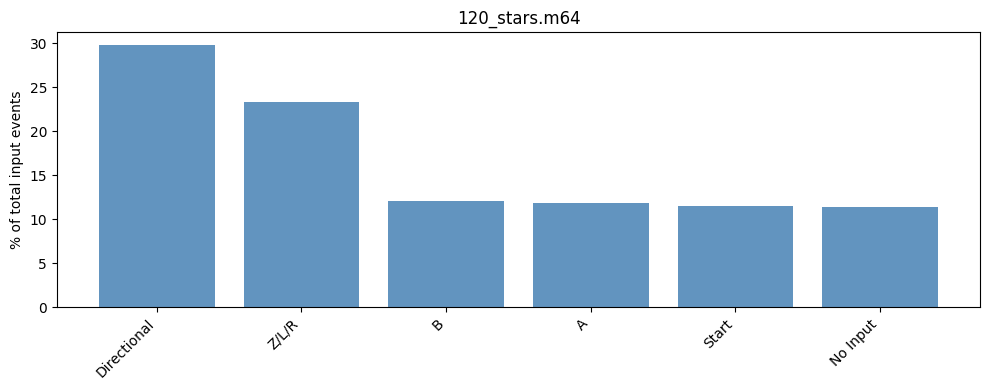

/tmp/ipykernel_1858/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


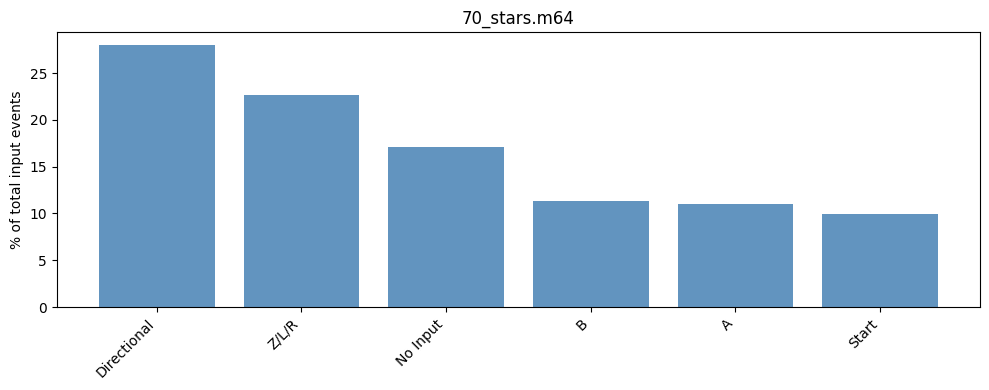

/tmp/ipykernel_1858/3039459278.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


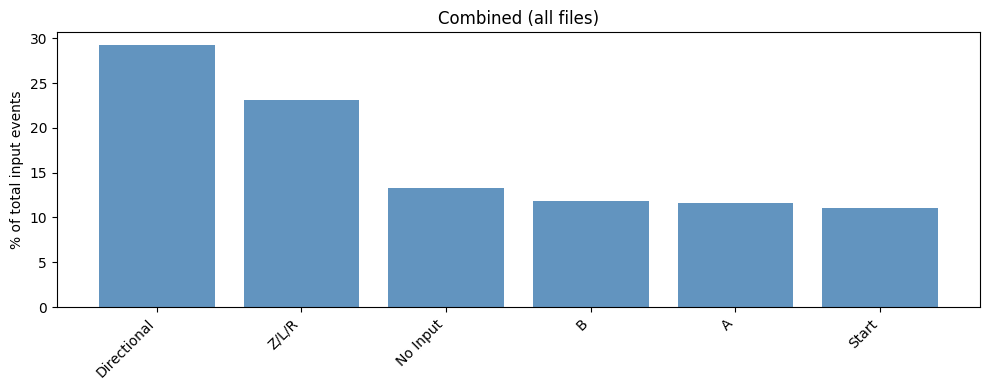

In [8]:
import matplotlib.pyplot as plt

def plot_activity(tensor, title):
    counts = tensor.sum(dim=0)
    pct    = counts / counts.sum() * 100

    # Sort descending so highest bar is on the left
    order  = pct.argsort(descending=True)
    names  = [CAT_NAMES[i] for i in order]
    values = pct[order].numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(names, values, color="steelblue", alpha=0.85)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel("% of total input events")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

offset = 0
for name, src in zip(dataset.file_names, SOURCES):
    n = expand_to_sequential(load_m64(src)).shape[0]
    plot_activity(dataset.data[offset : offset + n], name)
    offset += n

plot_activity(dataset.data, "Combined (all files)")

In [9]:
def entropy_bits(tensor: torch.Tensor) -> float:
    """Expected number of bits to encode one draw from the category distribution."""
    probs = tensor.sum(dim=0) / len(tensor)
    probs = probs[probs > 0]
    return -(probs * probs.log2()).sum().item()

uniform_entropy = torch.log2(torch.tensor(INPUT_DIM, dtype=torch.float)).item()
print(f"Entropy if {INPUT_DIM} categories were uniformly distributed: {uniform_entropy:.4f} bits\n")

offset = 0
for name, src in zip(dataset.file_names, SOURCES):
    n = expand_to_sequential(load_m64(src)).shape[0]
    h = entropy_bits(dataset.data[offset : offset + n])
    print(f"{name:40s}  H = {h:.4f} bits")
    offset += n

print()
print(f"{'Combined (all files)':40s}  H = {entropy_bits(dataset.data):.4f} bits")

Entropy if 6 categories were uniformly distributed: 2.5850 bits

120_stars.m64                             H = 2.4596 bits
70_stars.m64                              H = 2.4720 bits

Combined (all files)                      H = 2.4683 bits


In [10]:
import torch.nn as nn

LATENT_DIM  = 247
HIDDEN_DIM  = 512
INPUT_FLAT  = WINDOW_SIZE * INPUT_DIM


# ── Method 1: Sigmoid Annealing ───────────────────────────────────────────────
# β starts low (soft sigmoid) and increases each epoch toward hard binary.

class AnnealingAutoencoder(nn.Module):
    def __init__(self, beta_start=1.0, beta_end=20.0, anneal_epochs=50):
        super().__init__()
        self.enc1 = nn.Linear(INPUT_FLAT, HIDDEN_DIM)
        self.enc2 = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.dec1 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.dec2 = nn.Linear(HIDDEN_DIM, INPUT_FLAT)
        self.beta          = beta_start
        self.beta_start    = beta_start
        self.beta_end      = beta_end
        self.anneal_epochs = anneal_epochs

    def step_beta(self, epoch: int):
        t = min(epoch / self.anneal_epochs, 1.0)
        self.beta = self.beta_start + t * (self.beta_end - self.beta_start)

    def forward(self, x):
        h      = torch.relu(self.enc1(x))
        logits = self.enc2(h)
        z      = torch.sigmoid(self.beta * logits)
        out    = self.dec2(torch.relu(self.dec1(z)))
        return out.view(-1, WINDOW_SIZE, INPUT_DIM), z


# ── Method 2: Straight-Through Estimator ─────────────────────────────────────

class STEAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(INPUT_FLAT, HIDDEN_DIM)
        self.enc2 = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.dec1 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.dec2 = nn.Linear(HIDDEN_DIM, INPUT_FLAT)

    def forward(self, x):
        h      = torch.relu(self.enc1(x))
        logits = self.enc2(h)
        z_soft = torch.sigmoid(logits)
        z_hard = (z_soft > 0.5).float()
        z      = z_hard - z_soft.detach() + z_soft
        out    = self.dec2(torch.relu(self.dec1(z)))
        return out.view(-1, WINDOW_SIZE, INPUT_DIM), z_hard


# ── Loss ──────────────────────────────────────────────────────────────────────

def reconstruction_loss(logits, targets):
    labels = targets.argmax(dim=-1)
    return nn.functional.cross_entropy(
        logits.reshape(-1, INPUT_DIM),
        labels.reshape(-1),
    )


print("AnnealingAutoencoder params:", sum(p.numel() for p in AnnealingAutoencoder().parameters()))
print("STEAutoencoder params:      ", sum(p.numel() for p in STEAutoencoder().parameters()))

AnnealingAutoencoder params: 647799
STEAutoencoder params:       647799


In [ ]:
EPOCHS = 50
LR     = 1e-3

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()         else
    torch.device("cpu")
)
print(f"Using device: {device}")


def train(model, train_loader, test_loader, epochs, lr=LR):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_history, test_history = [], []

    for epoch in range(epochs):
        if hasattr(model, "step_beta"):
            model.step_beta(epoch)

        model.train()
        train_loss = 0.0
        for batch in train_loader:
            x = batch.to(device)
            optimizer.zero_grad()
            logits, _ = model(x.view(x.size(0), -1))
            loss = reconstruction_loss(logits, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_avg = train_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            test_avg = sum(
                reconstruction_loss(model(b.to(device).view(b.size(0), -1))[0], b.to(device)).item()
                for b in test_loader
            ) / len(test_loader)

        train_history.append(train_avg)
        test_history.append(test_avg)

        if (epoch + 1) % 5 == 0:
            extra = f"  β={model.beta:.2f}" if hasattr(model, "beta") else ""
            print(f"Epoch {epoch+1:3d}/{epochs}  train={train_avg:.4f}  test={test_avg:.4f}{extra}")

    return train_history, test_history


annealing_model = AnnealingAutoencoder().to(device)
ste_model       = STEAutoencoder().to(device)

if SAVE_MODELS and ANNEALING_PATH.exists() and STE_PATH.exists():
    print("Loading saved models ...")
    annealing_model.load_state_dict(torch.load(ANNEALING_PATH, map_location=device))
    ste_model.load_state_dict(torch.load(STE_PATH, map_location=device))
    annealing_model.eval()
    ste_model.eval()
    annealing_train = annealing_test = []
    ste_train = ste_test = []
    print("Done.")
else:
    print("── Annealing ──────────────────────────────")
    annealing_train, annealing_test = train(annealing_model, train_loader, test_loader, EPOCHS)

    print("\n── STE ────────────────────────────────────")
    ste_train, ste_test = train(ste_model, train_loader, test_loader, EPOCHS)

    if SAVE_MODELS:
        torch.save(annealing_model.state_dict(), ANNEALING_PATH)
        torch.save(ste_model.state_dict(), STE_PATH)
        print(f"\nModels saved to {MODEL_DIR.resolve()}")

if annealing_train and ste_train:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, name, tr, te in zip(axes,
                                 ["Annealing", "STE"],
                                 [annealing_train, ste_train],
                                 [annealing_test,  ste_test]):
        ax.plot(tr, label="Train")
        ax.plot(te, label="Test")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-entropy loss")
        ax.set_title(name)
        ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ── GitHub model sync ─────────────────────────────────────────────────────────
# Uploads trained models to GitHub, or downloads them to skip retraining.
#
# Colab workflow — new session:
#   1. Run cells up to and including this one (imports + config + helpers)
#   2. This cell downloads the saved models from GitHub
#   3. Run the training cell — it finds the local files and skips retraining
#
# Colab workflow — after training:
#   Run this cell to upload the newly trained models to GitHub

if not GITHUB_TOKEN:
    print("GITHUB_TOKEN not set — skipping GitHub sync.")
    print("Set it via Colab Secrets (key icon), then re-run the config cell.")
elif ANNEALING_PATH.exists() and STE_PATH.exists():
    print("Uploading models to GitHub ...")
    upload_to_github(ANNEALING_PATH, ANNEALING_REPO_PATH)
    upload_to_github(STE_PATH, STE_REPO_PATH)
    print("Done.")
else:
    print("Downloading models from GitHub ...")
    got_a = download_from_github(ANNEALING_REPO_PATH, ANNEALING_PATH)
    got_s = download_from_github(STE_REPO_PATH, STE_PATH)
    if got_a and got_s:
        print("Downloaded — run the training cell to load them (retraining will be skipped).")
    else:
        print("No saved models on GitHub yet — run the training cell first, then re-run this cell.")

In [12]:
sample = dataset[0].unsqueeze(0).to(device)   # (1, WINDOW_SIZE, INPUT_DIM)
x_flat = sample.view(1, -1)

print("── Input sequence (64 events) ──────────────────────────")
for i, row in enumerate(dataset[0]):
    cat = CAT_NAMES[row.argmax().item()]
    print(f"  [{i:2d}] {cat}")

print("\n── Annealing — binary latent (247 bits) ───────────────")
annealing_model.eval()
with torch.no_grad():
    _, z_anneal = annealing_model(x_flat)
bits_anneal = (z_anneal.squeeze() > 0.5).int().tolist()
print("  " + "".join(str(b) for b in bits_anneal))

print("\n── STE — binary latent (247 bits) ─────────────────────")
ste_model.eval()
with torch.no_grad():
    _, z_ste = ste_model(x_flat)
bits_ste = z_ste.squeeze().int().tolist()
print("  " + "".join(str(b) for b in bits_ste))

── Input sequence (64 events) ──────────────────────────
  [ 0] No Input
  [ 1] No Input
  [ 2] No Input
  [ 3] No Input
  [ 4] No Input
  [ 5] No Input
  [ 6] No Input
  [ 7] No Input
  [ 8] No Input
  [ 9] No Input
  [10] No Input
  [11] No Input
  [12] No Input
  [13] No Input
  [14] No Input
  [15] No Input
  [16] No Input
  [17] No Input
  [18] No Input
  [19] No Input
  [20] No Input
  [21] No Input
  [22] No Input
  [23] No Input
  [24] No Input
  [25] No Input
  [26] No Input
  [27] No Input
  [28] No Input
  [29] No Input
  [30] No Input
  [31] No Input
  [32] No Input
  [33] No Input
  [34] No Input
  [35] No Input
  [36] No Input
  [37] No Input
  [38] No Input
  [39] No Input
  [40] No Input
  [41] No Input
  [42] No Input
  [43] No Input
  [44] No Input
  [45] No Input
  [46] No Input
  [47] No Input
  [48] No Input
  [49] No Input
  [50] No Input
  [51] No Input
  [52] No Input
  [53] No Input
  [54] No Input
  [55] No Input
  [56] No Input
  [57] No Input
  [58] No Input

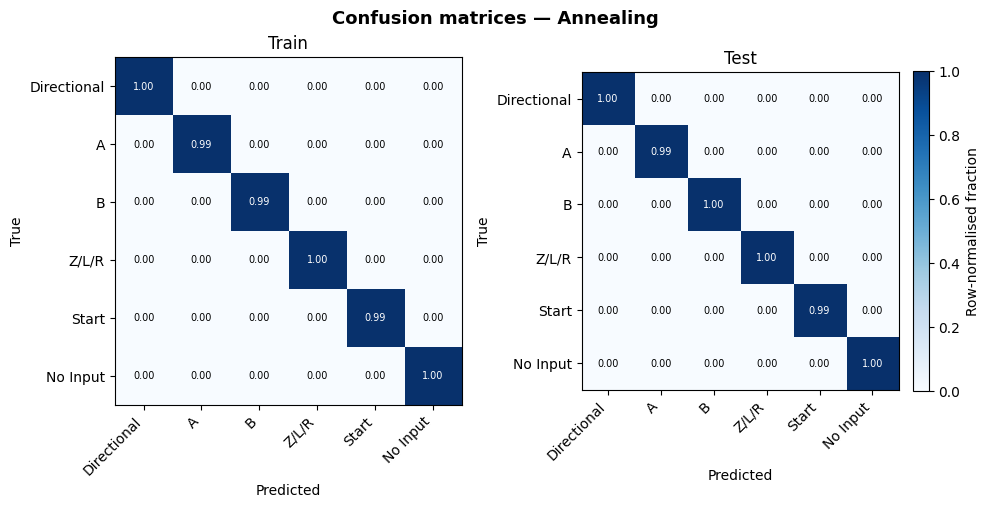

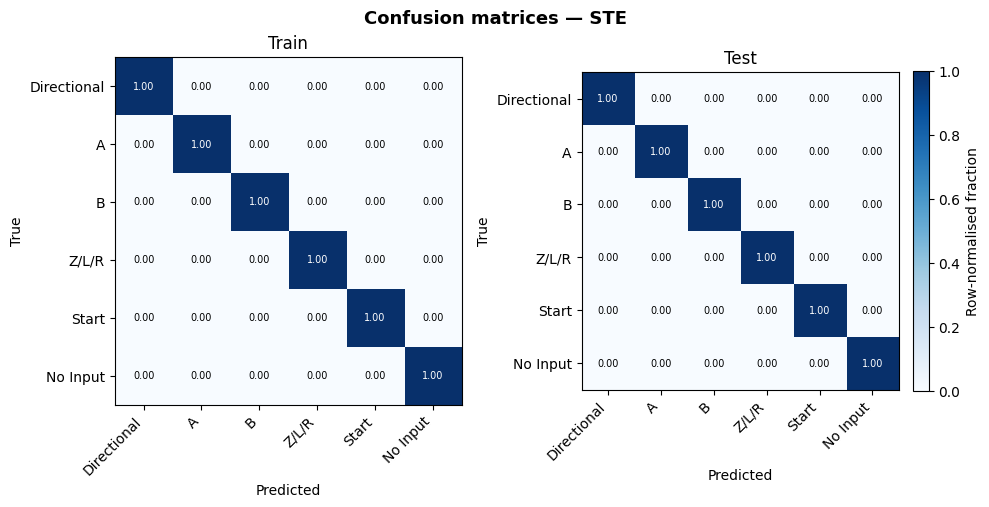

In [13]:

import numpy as np
import matplotlib.pyplot as plt

def confusion_matrix_for_model(model, data_tensor, batch_size=512):
    model.eval()
    trues, preds = [], []
    with torch.no_grad():
        for start in range(0, len(data_tensor) - WINDOW_SIZE, batch_size):
            end = min(start + batch_size, len(data_tensor) - WINDOW_SIZE)
            batch = torch.stack([data_tensor[i:i+WINDOW_SIZE] for i in range(start, end)])
            x = batch.to(device)
            logits, _ = model(x.view(x.size(0), -1))
            true_cls = x.argmax(dim=-1).cpu().numpy()
            pred_cls = logits.argmax(dim=-1).cpu().numpy()
            trues.append(true_cls.ravel())
            preds.append(pred_cls.ravel())
    return np.concatenate(trues), np.concatenate(preds)


def build_cm(trues, preds):
    cm = np.zeros((INPUT_DIM, INPUT_DIM), dtype=np.int64)
    for t, p in zip(trues, preds):
        cm[t, p] += 1
    return cm


def plot_confusion(cm, title, ax):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(INPUT_DIM)); ax.set_xticklabels(CAT_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(INPUT_DIM)); ax.set_yticklabels(CAT_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(INPUT_DIM):
        for j in range(INPUT_DIM):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                    color="white" if cm_norm[i,j] > 0.55 else "black", fontsize=7)
    return im


splits = [("Train", train_events), ("Test", test_events)]

eval_models = [("Annealing", annealing_model), ("STE", ste_model)]
n_splits = len(splits)

cms = {}  # (model_name, split_name) -> confusion matrix

for model_name, model in eval_models:
    fig, axes = plt.subplots(1, n_splits, figsize=(5 * n_splits, 5))
    fig.suptitle(f"Confusion matrices — {model_name}", fontsize=13, fontweight="bold")

    for ax, (split_name, data_slice) in zip(axes, splits):
        trues, preds = confusion_matrix_for_model(model, data_slice, batch_size=256)
        cm = build_cm(trues, preds)
        cms[(model_name, split_name)] = cm
        im = plot_confusion(cm, split_name, ax)

    fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label="Row-normalised fraction")
    plt.tight_layout()
    plt.show()


In [14]:

def metrics_from_cm(cm):
    """Per-class precision, recall, F1 and macro averages."""
    precs, recs, f1s = [], [], []
    for i in range(INPUT_DIM):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precs.append(p); recs.append(r); f1s.append(f)
    return precs, recs, f1s


col_w = 15
hdr = f"{'Class':<{col_w}}  {'Precision':>9}  {'Recall':>9}  {'F1':>9}"
sep = "─" * len(hdr)

for model_name, _ in eval_models:
    print(f"\n{'═'*len(hdr)}")
    print(f"  {model_name}")
    print(f"{'═'*len(hdr)}")

    for file_name, _ in splits:
        cm = cms[(model_name, file_name)]
        precs, recs, f1s = metrics_from_cm(cm)

        print(f"\n  {file_name}")
        print(f"  {hdr}")
        print(f"  {sep}")
        for cat, p, r, f in zip(CAT_NAMES, precs, recs, f1s):
            print(f"  {cat:<{col_w}}  {p:>9.4f}  {r:>9.4f}  {f:>9.4f}")
        print(f"  {sep}")
        print(f"  {'macro avg':<{col_w}}  {np.mean(precs):>9.4f}  {np.mean(recs):>9.4f}  {np.mean(f1s):>9.4f}")



════════════════════════════════════════════════
  Annealing
════════════════════════════════════════════════

  Train
  Class            Precision     Recall         F1
  ────────────────────────────────────────────────
  Directional         0.9964     0.9956     0.9960
  A                   0.9910     0.9928     0.9919
  B                   0.9948     0.9941     0.9944
  Z/L/R               0.9960     0.9958     0.9959
  Start               0.9929     0.9944     0.9936
  No Input            0.9955     0.9956     0.9955
  ────────────────────────────────────────────────
  macro avg           0.9944     0.9947     0.9946

  Test
  Class            Precision     Recall         F1
  ────────────────────────────────────────────────
  Directional         0.9961     0.9955     0.9958
  A                   0.9922     0.9928     0.9925
  B                   0.9958     0.9953     0.9956
  Z/L/R               0.9966     0.9962     0.9964
  Start               0.9929     0.9947     0.9938
  No 

Annealing: 122 committed bit-slots at ≥90% consistency


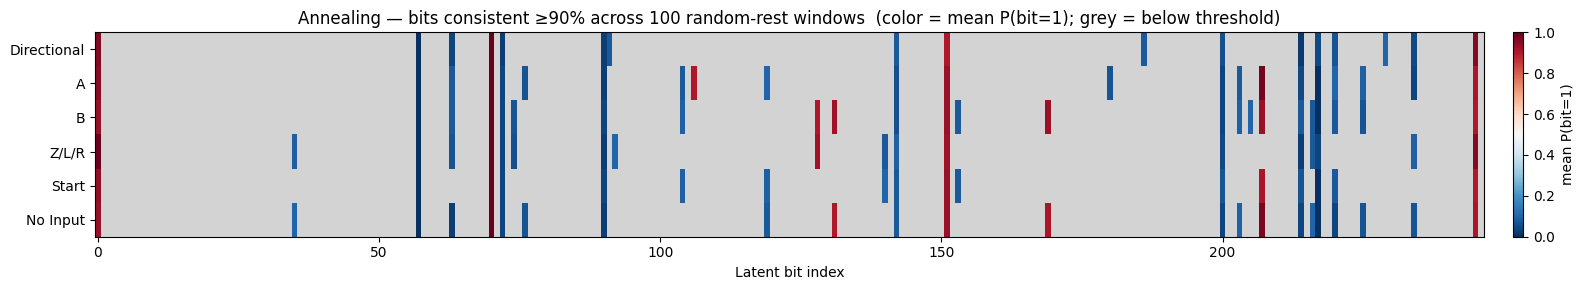

STE: 13 committed bit-slots at ≥90% consistency


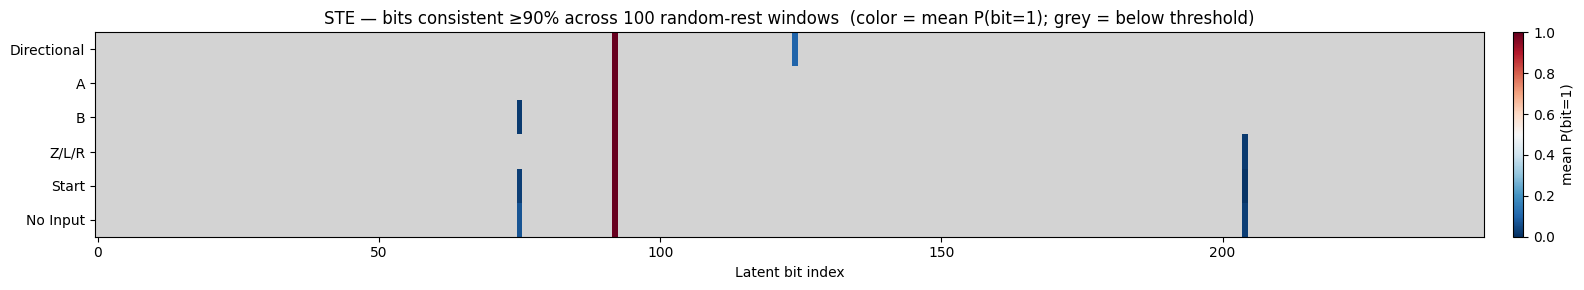

In [15]:

def bits_for_windows(model, windows, chunk=256):
    model.eval()
    parts = []
    with torch.no_grad():
        for s in range(0, len(windows), chunk):
            x = windows[s:s+chunk].to(device)
            _, z = model(x.view(x.size(0), -1))
            parts.append((z > 0.5).cpu().numpy().astype(np.float32))
    return np.concatenate(parts, axis=0)   # (n, LATENT_DIM)


torch.manual_seed(42)
N_RANDOM   = 100
THRESHOLD  = 0.90
eye        = torch.eye(INPUT_DIM)

rest_idx     = torch.randint(0, INPUT_DIM, (N_RANDOM, WINDOW_SIZE - 1))
shared_rests = eye[rest_idx]   # (100, 63, 6)

for model_name, model in [("Annealing", annealing_model), ("STE", ste_model)]:

    # Store actual mean values; mask out anything below threshold
    display = np.full((INPUT_DIM, LATENT_DIM), np.nan)
    for first_cat in range(INPUT_DIM):
        first   = eye[first_cat].unsqueeze(0).unsqueeze(0).expand(N_RANDOM, 1, -1)
        windows = torch.cat([first, shared_rests], dim=1)
        mean    = bits_for_windows(model, windows).mean(axis=0)   # (247,)
        mask    = (mean >= THRESHOLD) | (mean <= 1 - THRESHOLD)
        display[first_cat, mask] = mean[mask]

    n_committed = (~np.isnan(display)).sum()
    print(f"{model_name}: {n_committed} committed bit-slots at ≥{int(THRESHOLD*100)}% consistency")

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color="lightgrey")

    fig, ax = plt.subplots(figsize=(16, 3))
    im = ax.imshow(display, aspect="auto", vmin=0, vmax=1,
                   cmap=cmap, interpolation="nearest")
    ax.set_yticks(range(INPUT_DIM))
    ax.set_yticklabels(CAT_NAMES)
    ax.set_xlabel("Latent bit index")
    ax.set_title(
        f"{model_name} — bits consistent ≥{int(THRESHOLD*100)}% across {N_RANDOM} random-rest windows  "
        f"(color = mean P(bit=1); grey = below threshold)"
    )
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="mean P(bit=1)")
    plt.tight_layout()
    plt.show()


════════════════════════════════════════════════════════════
  Experiment 1: all-same windows  [X, X, ..., X]
════════════════════════════════════════════════════════════


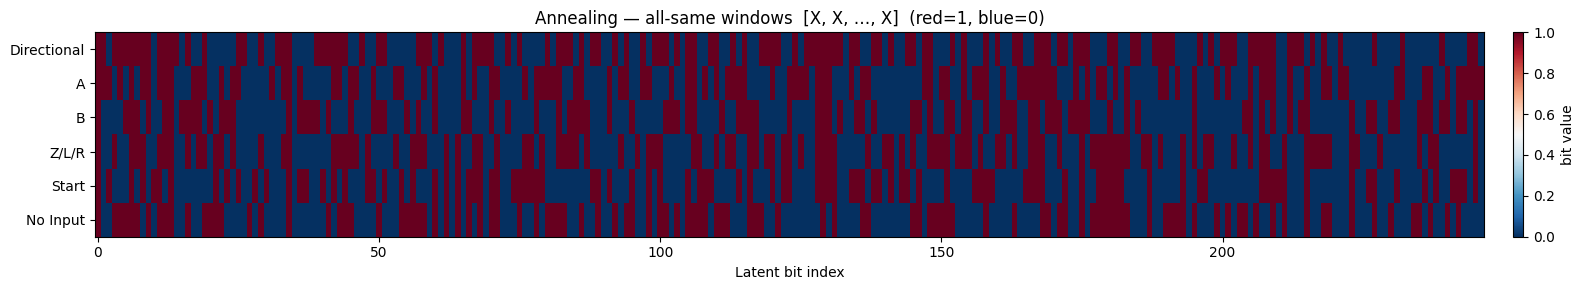

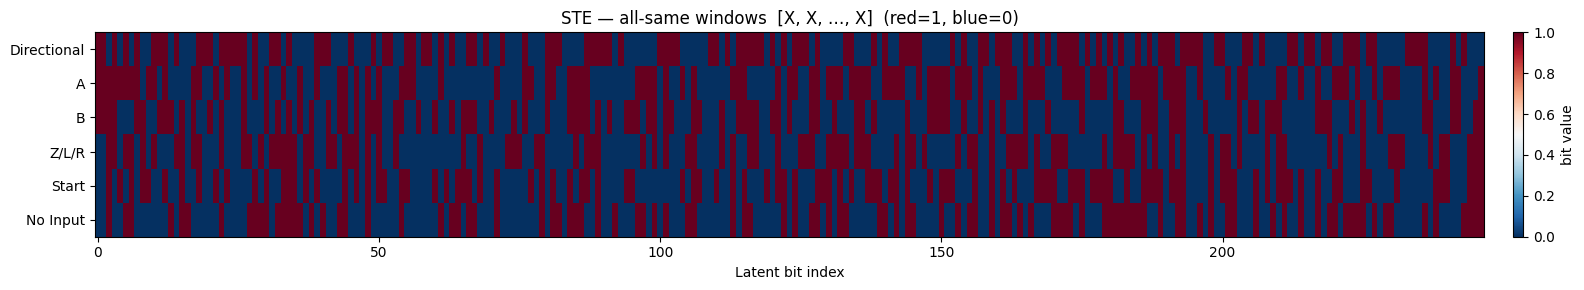


════════════════════════════════════════════════════════════
  Experiment 2: majority sweep
  K events of category X  +  (64-K) random events
════════════════════════════════════════════════════════════


/tmp/ipykernel_1858/3793414691.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


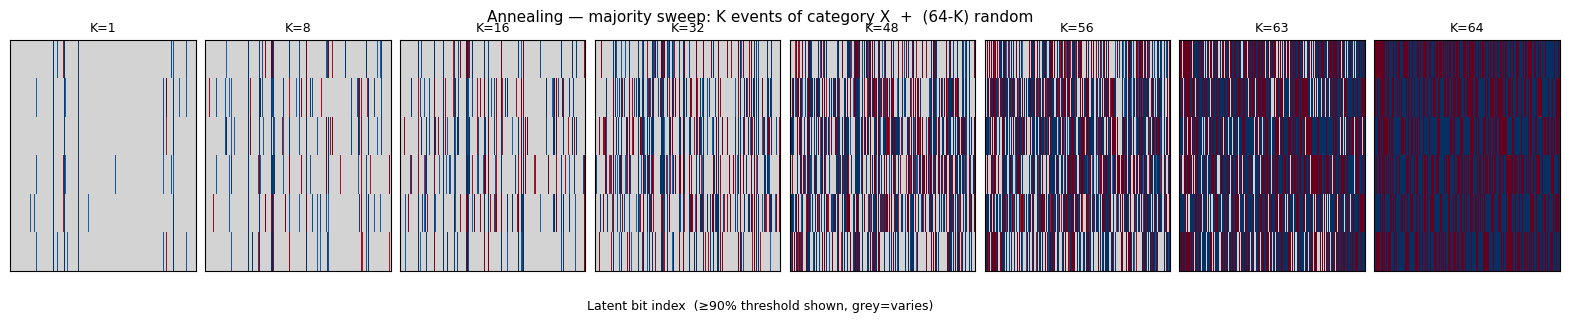

/tmp/ipykernel_1858/3793414691.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


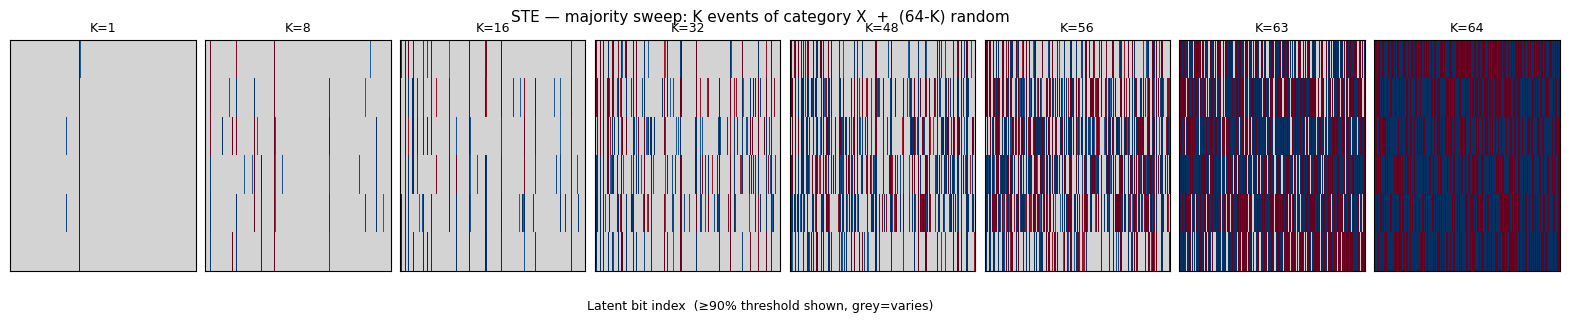

In [16]:

def bits_for_windows(model, windows, chunk=256):
    model.eval()
    parts = []
    with torch.no_grad():
        for s in range(0, len(windows), chunk):
            x = windows[s:s+chunk].to(device)
            _, z = model(x.view(x.size(0), -1))
            parts.append((z > 0.5).cpu().numpy().astype(np.float32))
    return np.concatenate(parts, axis=0)   # (n, LATENT_DIM)


torch.manual_seed(42)
eye       = torch.eye(INPUT_DIM)
THRESHOLD = 0.90

# ── Experiment 1: all-same windows ───────────────────────────────────────────
# Each window is [X, X, X, ..., X] — maximum possible category signal.

print("═" * 60)
print("  Experiment 1: all-same windows  [X, X, ..., X]")
print("═" * 60)

for model_name, model in [("Annealing", annealing_model), ("STE", ste_model)]:

    display = np.full((INPUT_DIM, LATENT_DIM), np.nan)
    for cat in range(INPUT_DIM):
        window = eye[cat].unsqueeze(0).expand(WINDOW_SIZE, -1).unsqueeze(0)  # (1, 64, 6)
        bits   = bits_for_windows(model, window).squeeze()                    # (247,)
        # Single deterministic window — bit is either 0 or 1, always "committed"
        display[cat] = bits

    cmap = plt.cm.RdBu_r.copy()
    fig, ax = plt.subplots(figsize=(16, 3))
    im = ax.imshow(display, aspect="auto", vmin=0, vmax=1, cmap=cmap, interpolation="nearest")
    ax.set_yticks(range(INPUT_DIM))
    ax.set_yticklabels(CAT_NAMES)
    ax.set_xlabel("Latent bit index")
    ax.set_title(f"{model_name} — all-same windows  [X, X, …, X]  (red=1, blue=0)")
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="bit value")
    plt.tight_layout()
    plt.show()


# ── Experiment 2: majority sweep ──────────────────────────────────────────────
# K events of category X, then (64-K) random events.  Sweep K across the window.

print("\n" + "═" * 60)
print("  Experiment 2: majority sweep")
print("  K events of category X  +  (64-K) random events")
print("═" * 60)

N_RANDOM  = 100
K_VALUES  = [1, 8, 16, 32, 48, 56, 63, 64]

# Shared random pool for the non-X portion
rand_pool = eye[torch.randint(0, INPUT_DIM, (N_RANDOM, WINDOW_SIZE))].numpy()  # (100, 64, 6)

for model_name, model in [("Annealing", annealing_model), ("STE", ste_model)]:

    # mean_tensor: (n_K, INPUT_DIM, LATENT_DIM)
    mean_by_K = []
    for K in K_VALUES:
        means = np.zeros((INPUT_DIM, LATENT_DIM))
        for cat in range(INPUT_DIM):
            cat_row = eye[cat].numpy()                       # (6,)
            windows = rand_pool.copy()                       # (100, 64, 6)
            windows[:, :K, :] = cat_row                     # first K positions = cat X
            t = torch.from_numpy(windows).float()
            means[cat] = bits_for_windows(model, t).mean(axis=0)
        mean_by_K.append(means)

    fig, axes = plt.subplots(1, len(K_VALUES), figsize=(20, 3),
                             sharey=True, gridspec_kw={"wspace": 0.05})
    fig.suptitle(f"{model_name} — majority sweep: K events of category X  +  (64-K) random",
                 fontsize=11)

    cmap = plt.cm.RdBu_r.copy()
    for ax, K, means in zip(axes, K_VALUES, mean_by_K):
        display = np.full_like(means, np.nan)
        display[means >= THRESHOLD] = means[means >= THRESHOLD]
        display[means <= 1 - THRESHOLD] = means[means <= 1 - THRESHOLD]
        cmap2 = plt.cm.RdBu_r.copy()
        cmap2.set_bad("lightgrey")
        ax.imshow(display, aspect="auto", vmin=0, vmax=1, cmap=cmap2, interpolation="nearest")
        ax.set_title(f"K={K}", fontsize=9)
        ax.set_xticks([])
        if ax == axes[0]:
            ax.set_yticks(range(INPUT_DIM))
            ax.set_yticklabels(CAT_NAMES, fontsize=8)
        else:
            ax.set_yticks([])

    fig.text(0.5, -0.02, "Latent bit index  (≥90% threshold shown, grey=varies)",
             ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
